170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


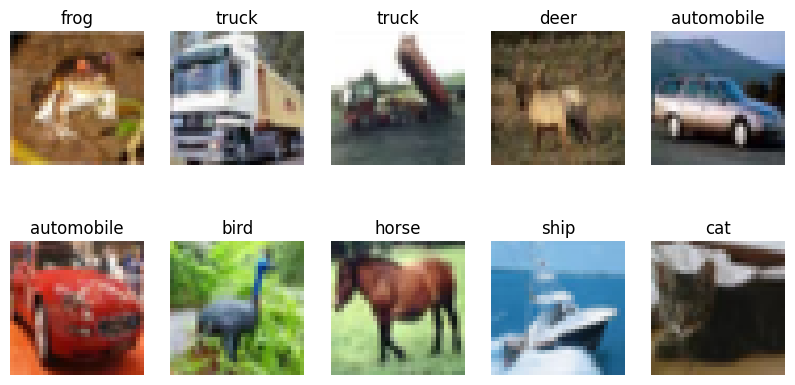

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 55s 43ms/step - accuracy: 0.4363 - loss: 1.5417 - val_accuracy: 0.5214 - val_loss: 1.3207
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 53s 42ms/step - accuracy: 0.5814 - loss: 1.1829 - val_accuracy: 0.6122 - val_loss: 1.0930
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 53s 42ms/step - accuracy: 0.6385 - loss: 1.0274 - val_accuracy: 0.6508 - val_loss: 0.9956
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.6747 - loss: 0.9267 - val_accuracy: 0.6705 - val_loss: 0.9385
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.7017 - loss: 0.8517 - val_accuracy: 0.6717 - val_loss: 0.9521
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.7214 - loss: 0.7934 - val_accuracy: 0.6918 - val_loss: 0.8802
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 41ms/step - accuracy: 0.7416 - loss: 0.7373 - val_accuracy: 0.6730 - val_loss: 0.9526
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.7577 -

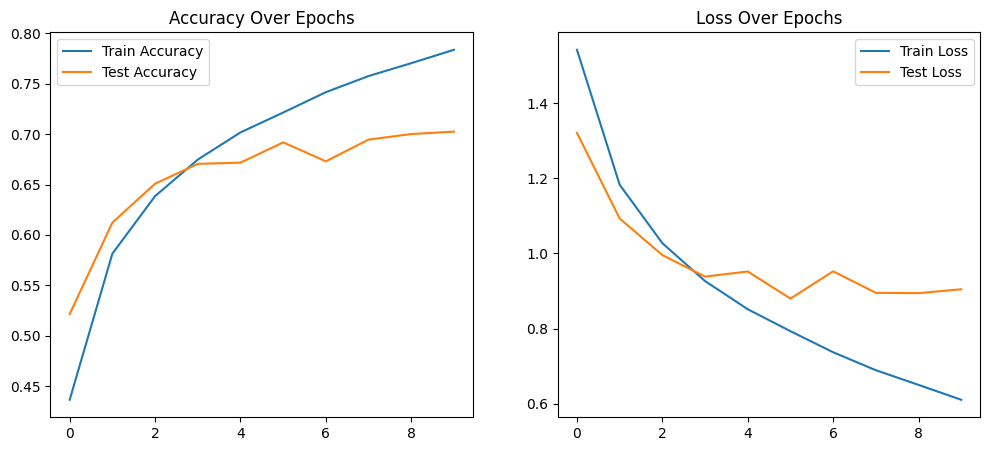

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


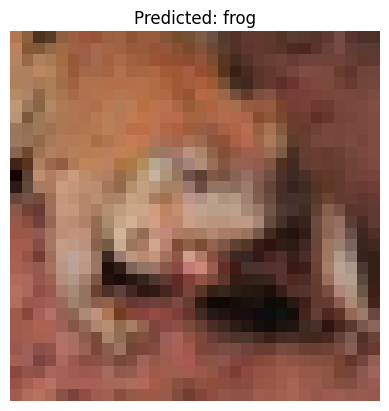

              precision    recall  f1-score   support

           0       0.69      0.78      0.73      1000
           1       0.79      0.86      0.82      1000
           2       0.55      0.65      0.60      1000
           3       0.55      0.47      0.51      1000
           4       0.67      0.63      0.65      1000
           5       0.56      0.64      0.60      1000
           6       0.79      0.75      0.77      1000
           7       0.76      0.73      0.75      1000
           8       0.87      0.74      0.80      1000
           9       0.82      0.71      0.77      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



In [1]:
# CNN Image Classification using TensorFlow (CIFAR-10)
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize Data
X_train = X_train / 255.0
X_test = X_test / 255.0

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Visualize Sample Images
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

# Build CNN Model
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2
)

# Evaluate Model
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.legend()
plt.title("Accuracy Over Epochs")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.legend()
plt.title("Loss Over Epochs")

plt.show()

# Make Predictions
predictions = model.predict(X_test)

index = 5
plt.imshow(X_test[index])
plt.title("Predicted: " + class_names[np.argmax(predictions[index])])
plt.axis("off")
plt.show()


# Classification Report
from sklearn.metrics import classification_report

y_pred = np.argmax(predictions, axis=1)
print(classification_report(y_test, y_pred))

In [2]:
model.save("cnn_model.keras")
from google.colab import files
files.download("cnn_model.keras")
model.summary()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 367,712 (1.40 MB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 245,142 (957.59 KB)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


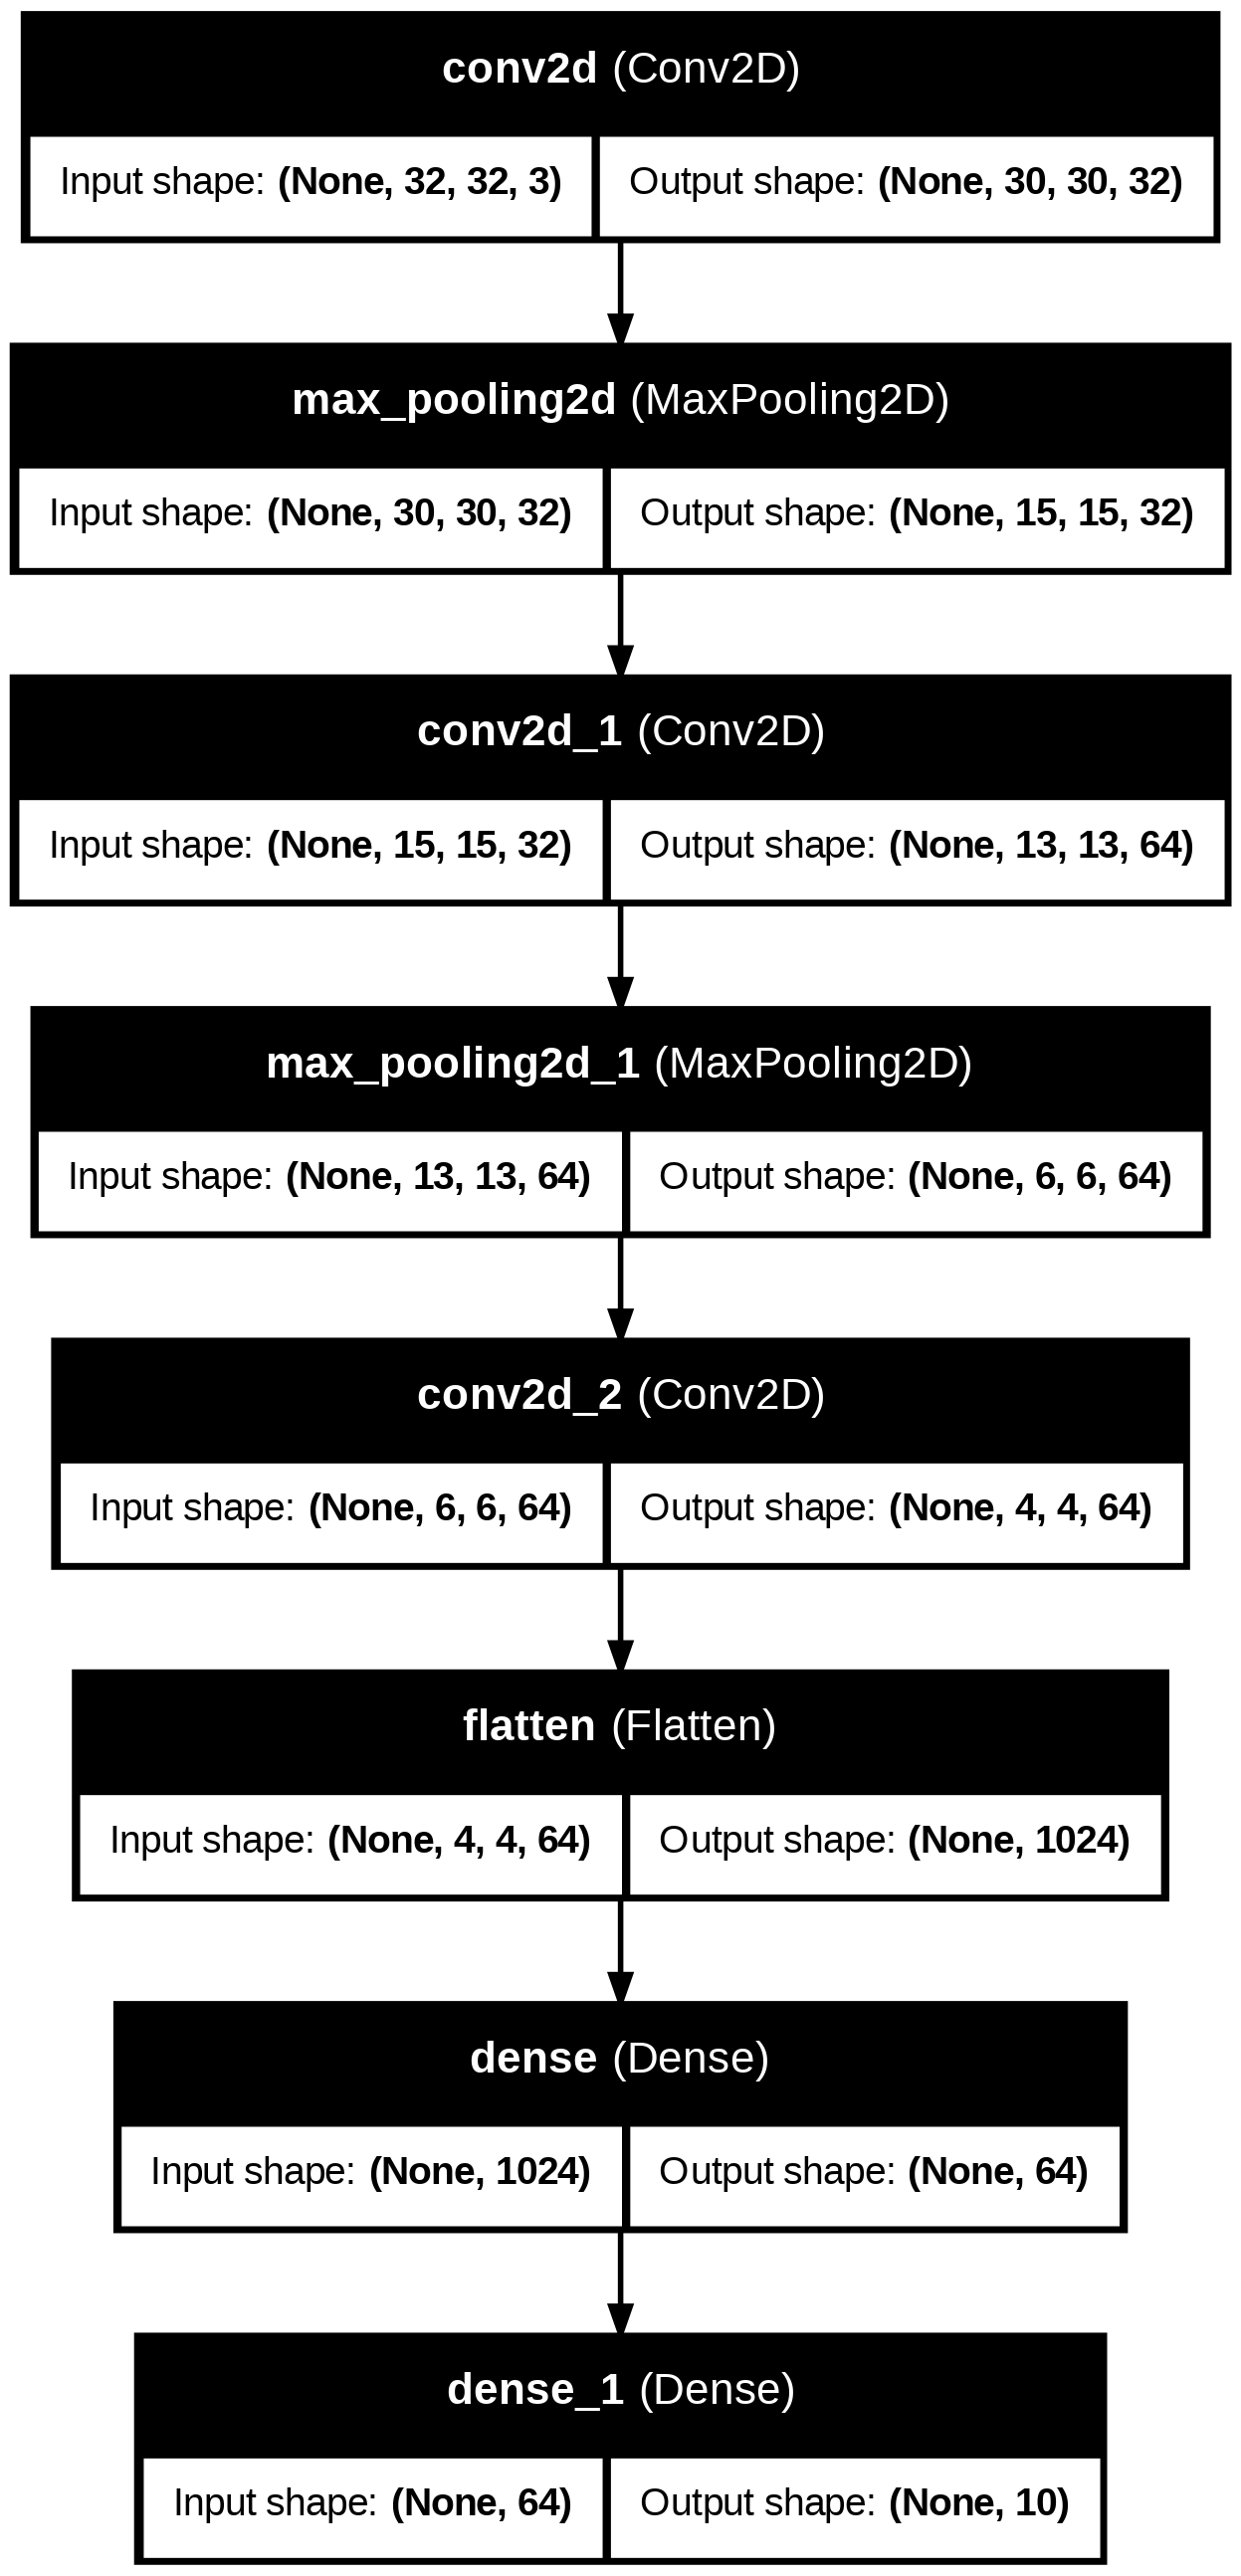

In [3]:
!apt-get install -y graphviz
!pip install pydot

from tensorflow.keras.utils import plot_model

plot_model(
    model,
    show_shapes=True,
    show_layer_names=True
)